In [ ]:
import numpy as np
import matplotlib.pyplot as plt

C_AUD = "#1f77b4"   # blue (auditory)
C_VIS = "#d62728"   # red  (visual)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})

/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/797736388.py:15: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/797736388.py:16: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.savefig("figures_poster/bar_C1.svg", transparent=True)
/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/797736388.py:17: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.savefig("figures_poster/bar_C1.pdf", transparent=True)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp
/opt/miniconda3/envs/mathmod/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


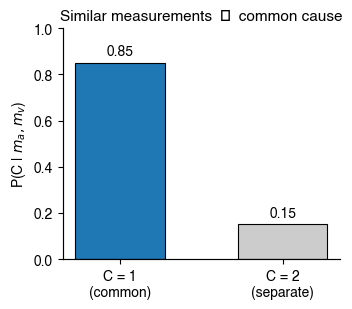

In [ ]:
# C = 1 : common cause (m_a ≈ m_v → posterior favours one source)
p = [0.85, 0.15]
labels = ["C = 1\n(common)", "C = 2\n(separate)"]

fig, ax = plt.subplots(figsize=(3.6, 3.2))
bars = ax.bar(labels, p, color=[C_AUD, "#cccccc"], width=0.55,
              edgecolor="black", linewidth=0.8)
for b, v in zip(bars, p):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 1)
ax.set_ylabel("P(C | $m_a, m_v$)")
ax.set_title("Similar measurements  →  common cause", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures_poster/bar_C1.svg", transparent=True)
plt.savefig("figures_poster/bar_C1.pdf", transparent=True)
plt.show()

/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/2258299795.py:15: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/2258299795.py:16: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.savefig("figures_poster/bar_C2.svg", transparent=True)
/var/folders/_p/yywkspd92qs_6p63bz38bswr0000gn/T/ipykernel_70503/2258299795.py:17: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Helvetica.
  plt.savefig("figures_poster/bar_C2.pdf", transparent=True)
1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


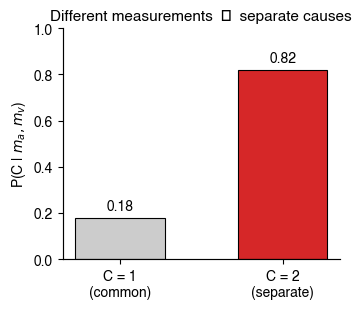

In [ ]:
# C = 2 : separate causes (m_a ≠ m_v → posterior favours independent sources)
p = [0.18, 0.82]
labels = ["C = 1\n(common)", "C = 2\n(separate)"]

fig, ax = plt.subplots(figsize=(3.6, 3.2))
bars = ax.bar(labels, p, color=["#cccccc", C_VIS], width=0.55,
              edgecolor="black", linewidth=0.8)
for b, v in zip(bars, p):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 1)
ax.set_ylabel("P(C | $m_a, m_v$)")
ax.set_title("Different measurements  →  separate causes", fontsize=11)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("figures_poster/bar_C2.svg", transparent=True)
plt.savefig("figures_poster/bar_C2.pdf", transparent=True)
plt.show()

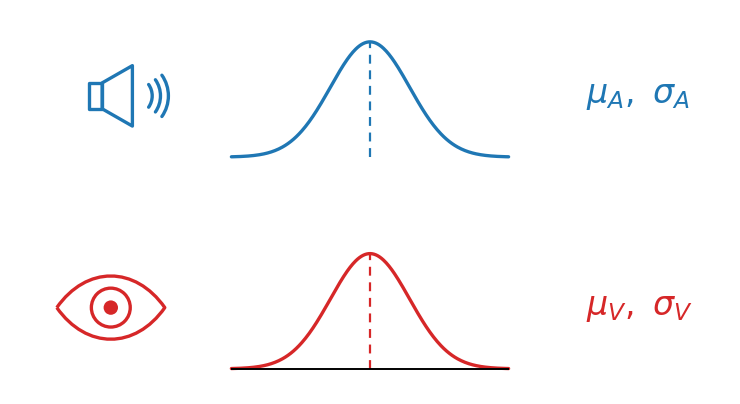

In [25]:
# Sensory encoding icons + Gaussians
from matplotlib.patches import Rectangle, Polygon, Circle, Arc, PathPatch
from matplotlib.path import Path


def draw_speaker(ax, cx, cy, color, lw=2.4, s=1.0):
    ax.add_patch(Rectangle((cx - 0.30*s, cy - 0.18*s), 0.18*s, 0.36*s,
                           facecolor="none", edgecolor=color, lw=lw,
                           joinstyle="round"))
    cone = Polygon([(cx - 0.12*s, cy - 0.18*s),
                    (cx - 0.12*s, cy + 0.18*s),
                    (cx + 0.30*s, cy + 0.42*s),
                    (cx + 0.30*s, cy - 0.42*s)],
                   closed=True, facecolor="none",
                   edgecolor=color, lw=lw, joinstyle="round")
    ax.add_patch(cone)
    for r in (0.55, 0.78, 1.00):
        ax.add_patch(Arc((cx + 0.30*s, cy), r*s, r*s,
                         theta1=-35, theta2=35,
                         color=color, lw=lw, capstyle="round"))


def draw_eye(ax, cx, cy, color, lw=2.4, s=1.0):
    w, h = 0.75*s, 0.45*s
    verts = [
        (cx - w, cy),
        (cx - 0.45*w, cy + 1.30*h), (cx + 0.45*w, cy + 1.30*h), (cx + w, cy),
        (cx + 0.45*w, cy - 1.30*h), (cx - 0.45*w, cy - 1.30*h), (cx - w, cy),
    ]
    codes = [Path.MOVETO,
             Path.CURVE4, Path.CURVE4, Path.CURVE4,
             Path.CURVE4, Path.CURVE4, Path.CURVE4]
    ax.add_patch(PathPatch(Path(verts, codes), facecolor="none",
                           edgecolor=color, lw=lw, joinstyle="round"))
    ax.add_patch(Circle((cx, cy), 0.27*s, facecolor="none",
                        edgecolor=color, lw=lw))
    ax.add_patch(Circle((cx, cy), 0.10*s, facecolor=color, edgecolor="none"))


def draw_modality_row(ax, color, icon_fn, mu_label, *, draw_x_axis=False):
    baseline_y = 0.15
    ax.set_xlim(0, 10); ax.set_ylim(-0.2, 2.2)
    ax.set_aspect("equal"); ax.axis("off")

    icon_fn(ax, cx=1.4, cy=1.0, color=color)

    xs = np.linspace(-3.5, 3.5, 300)
    ys = np.exp(-0.5 * xs**2)
    gx = xs * 0.55 + 5.0
    gy = ys * 1.6 + baseline_y
    ax.plot(gx, gy, color=color, lw=2.4, solid_capstyle="round")
    ax.plot([5.0, 5.0], [baseline_y, baseline_y + 1.6], color=color, lw=1.6,
            linestyle=(0, (4, 3)))

    if draw_x_axis:
        ax.plot([gx.min(), gx.max()], [baseline_y, baseline_y],
                color="black", lw=1.4, solid_capstyle="butt")

    ax.text(8.0, 1.0, mu_label, color=color, fontsize=24, va="center",
            ha="left")


fig, axes = plt.subplots(2, 1, figsize=(7.5, 4.6), sharex=True)
draw_modality_row(axes[0], C_AUD, draw_speaker, r"$\mu_A,\ \sigma_A$")
draw_modality_row(axes[1], C_VIS, draw_eye,     r"$\mu_V,\ \sigma_V$", draw_x_axis=True)

plt.tight_layout()
plt.savefig("figures_poster/encoding_icons.svg", transparent=True)
plt.savefig("figures_poster/encoding_icons.pdf", transparent=True)
plt.savefig("figures_poster/encoding_icons.png", dpi=300, transparent=True)
plt.show()